<h1 style="font-size:48px; text-align:center;">Peaucellier-Lipkin mechanisme: analyse</h1>

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Mobiliteit van de mechanisme </h3>
De Chebychev–Grübler–Kutzbach formule voor mobiliteit in een vlak geeft: 

$$M = {\color{red}3}(n − 1) − {\color{blue}2}f_1 − f_2$$

Met:

$n = 10$

$f_1 = 13 $

$f_2 = 0 $

Wat geeft $M = 1$


</div> 

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

#geometrische parameters

r2  = 0.15
r1  = 0.15
r5l = 0.12
r5h = 0.12
r4l = 0.12
r4h = 0.12

phi2_init  = 0.0
phi4h_init =  math.pi/3
phi4l_init = -math.pi/3

r3l = math.sqrt((r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init))**2 +
                (      r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init))**2)

r3h = math.sqrt((r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init))**2 +
                (      r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init))**2)

r3h_ext = r3h

phi3h_init = math.atan2((r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init)),
                        (r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init)))

phi3l_init = math.atan2((r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init)),
                        (r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init)))

# Crank-slider
r_crank  = 0.12
L_bielle = 0.25
F = np.array([-0.36, -0.32])


ModuleNotFoundError: No module named 'numpy'

In [ ]:
#tijd en driver definitie

t_begin = 0.0
t_end   = 25.0
Ts      = 0.05
t = np.arange(t_begin, t_end + Ts, Ts)

omega_crank = 0.2
theta_crank = omega_crank * t


In [ ]:
#Rotatie van vector

def rotate_vector(z, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return R @ z


In [ ]:
#Sluitingsvergelijkingen

def system_equations(x, theta_k):
    phi2, phi3h, phi4h, phi3l, phi4l = x  # x houdt de 5 hoeken die we zoeken en theta_k is de hoek vd crank

    # high lus
    F1 = r1 + r2*np.cos(phi2) + r4h*np.cos(phi4h) - r3h*np.cos(phi3h)
    F2 =      r2*np.sin(phi2) + r4h*np.sin(phi4h) - r3h*np.sin(phi3h)

    # low lus
    F3 = r1 + r2*np.cos(phi2) + r4l*np.cos(phi4l) - r3l*np.cos(phi3l)
    F4 =      r2*np.sin(phi2) + r4l*np.sin(phi4l) - r3l*np.sin(phi3l)

    # Extentie van r3h + crank-slider
    C = np.array([0.0, 0.0])
    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h + np.pi) #uiteinde van extensie van r3h is op een hoek phi3h + pi
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_k)

    F5 = (E[0] - Q[0])**2 + (E[1] - Q[1])**2 - L_bielle**2  # afstand tussen E en Q moet altijd L_bielle zijn

    return [F1, F2, F3, F4, F5]


In [ ]:
# kinematische resolutie

phi2  = np.zeros_like(t)
phi3h = np.zeros_like(t)
phi4h = np.zeros_like(t)
phi3l = np.zeros_like(t)
phi4l = np.zeros_like(t)

x_guess = np.array([phi2_init, phi3h_init, phi4h_init, phi3l_init, phi4l_init])

for k in range(len(t)):
    theta_k = theta_crank[k]
    sol = fsolve(lambda x: system_equations(x, theta_k), x_guess)  #geeft de oplossing van de sluitingsvgls, dus F1, F2, F3,... = 0
    phi2[k], phi3h[k], phi4h[k], phi3l[k], phi4l[k] = sol
    x_guess = sol  # we gebruiken de gevonden oplossing voor het volgende tijdstip


In [ ]:
# Animatie

# window view mechanism
x_left   = -0.40
x_right  =  0.40
y_bottom = -0.50
y_top    =  0.30


C = np.array([0.0, 0.0])

plt.ioff()
fig, ax = plt.subplots()

t_size = len(t)
frames = t_size / 5
delta = int(np.floor(t_size / frames))
index_vec = np.arange(0, t_size, delta, dtype=int)
#of als je niet enkel 1 op de 5 frames wilt tonen, veranderen naar:
#t_size = len(t)
#index_vec = np.arange(t_size)


def update(frame_idx):
    k = index_vec[frame_idx]

    ax.cla()
    ax.axis('equal')
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_title(f'Frame {k}')

    # Base : C -> A -> B
    A = C + np.array([r1, 0.0])
    B = A + rotate_vector(np.array([r2, 0.0]), phi2[k])

    # High / low branch
    D_h = B + rotate_vector(np.array([r4h, 0.0]), phi4h[k])
    D_l = B + rotate_vector(np.array([r4l, 0.0]), phi4l[k])
    P   = D_h + (D_l - B)

    loop_ground  = np.array([C, A, B])
    loop_rhombus = np.array([B, D_h, P, D_l, B])
    loop_r3h     = np.array([C, D_h])
    loop_r3l     = np.array([C, D_l])

    ax.plot(loop_ground[:,0],  loop_ground[:,1],  '-o')
    ax.plot(loop_rhombus[:,0], loop_rhombus[:,1], '-o')
    ax.plot(loop_r3h[:,0],     loop_r3h[:,1],     '-o', color='purple', linewidth=2)
    ax.plot(loop_r3l[:,0],     loop_r3l[:,1],     '-o', color='green', linewidth=2)

    # verticale stippellijn
    xP = P[0]
    ax.plot([xP, xP], [y_bottom, y_top], '--', color='lightgray', linewidth=1)

    # Extensie
    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h[k] + np.pi)
    ax.plot([C[0], E[0]], [C[1], E[1]], '-o', color='purple', linewidth=2)

    # Crank-slider
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_crank[k])
    ax.plot([F[0], Q[0]], [F[1], Q[1]], '-o', color='green', linewidth=2)
    ax.plot([Q[0], E[0]], [Q[1], E[1]], '-o', color='green', linewidth=2)

    return ax


ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)
HTML(ani.to_jshtml())


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

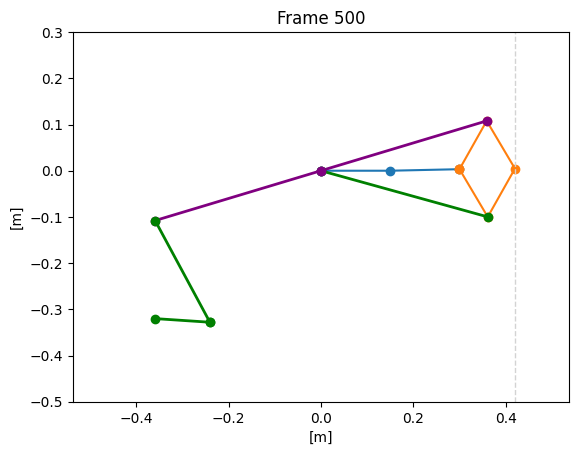

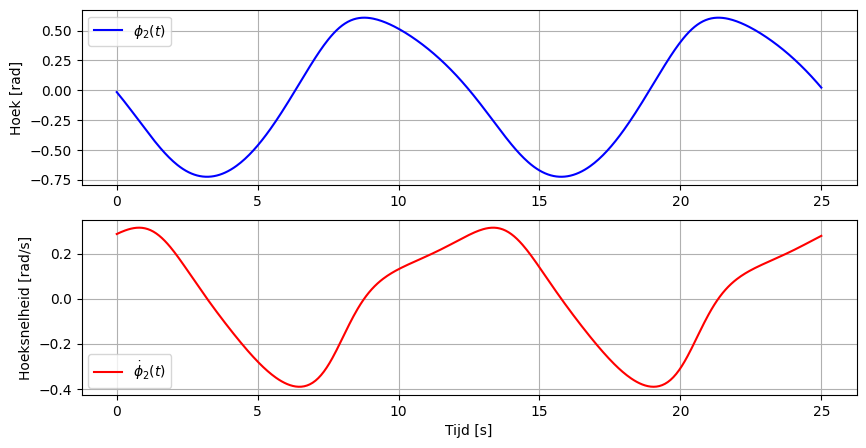

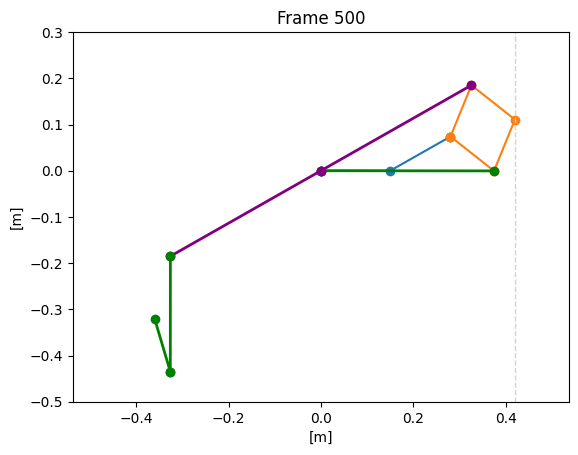

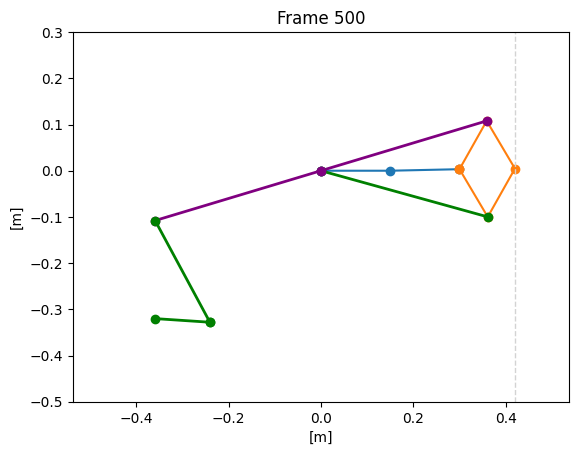

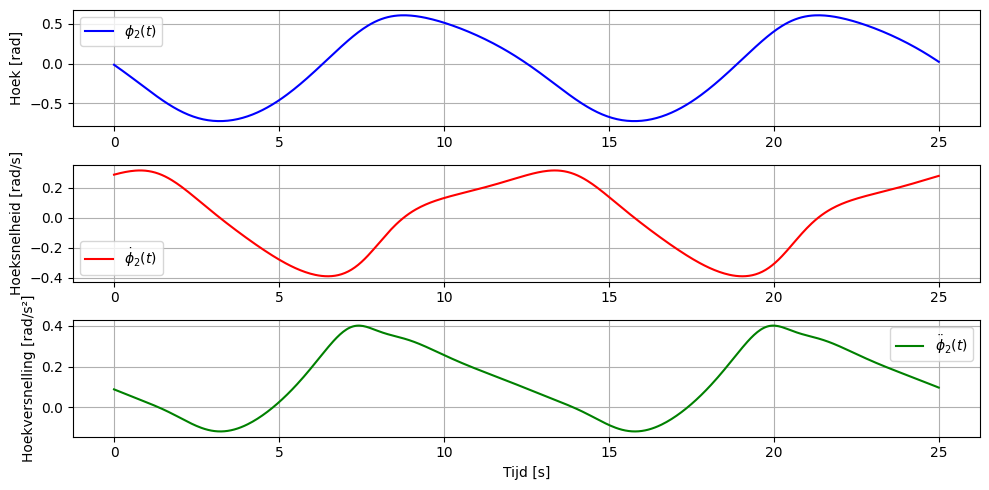

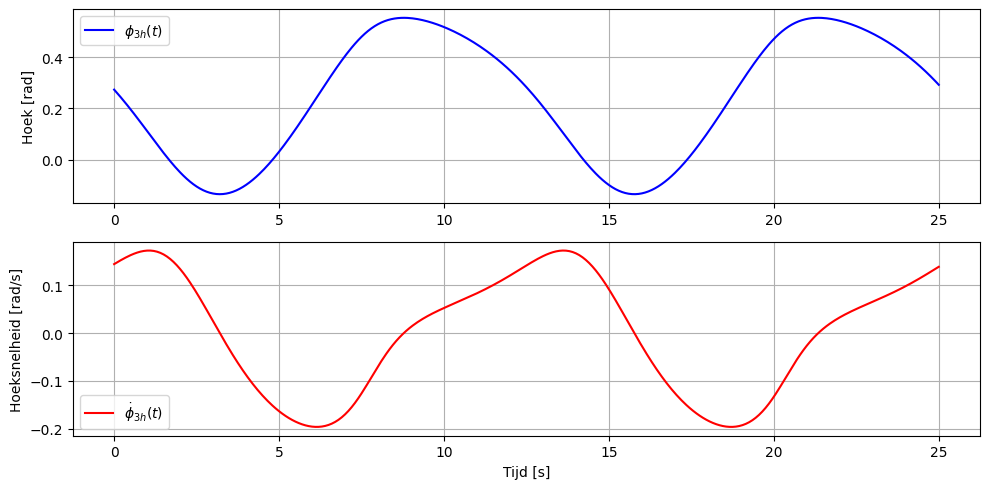

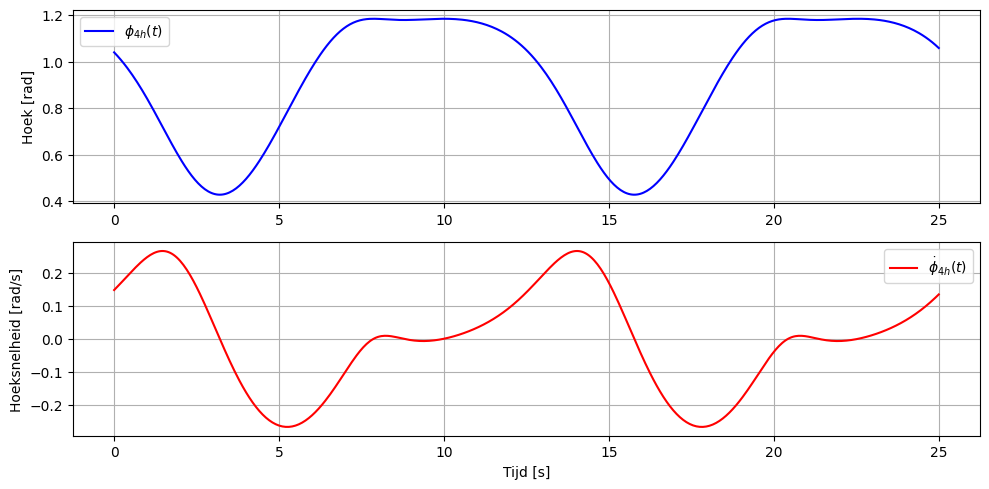

: 

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

#geometrische parameters

r2  = 0.15
r1  = 0.15
r5l = 0.12
r5h = 0.12
r4l = 0.12
r4h = 0.12

phi2_init  = 0.0
phi4h_init =  math.pi/3
phi4l_init = -math.pi/3

r3l = math.sqrt((r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init))**2 +
                (      r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init))**2)

r3h = math.sqrt((r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init))**2 +
                (      r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init))**2)

r3h_ext = r3h

phi3h_init = math.atan2((r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init)),
                        (r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init)))

phi3l_init = math.atan2((r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init)),
                        (r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init)))

# Crank-slider
r_crank  = 0.12
L_bielle = 0.25
F = np.array([-0.36, -0.32])

#tijd en driver definitie

t_begin = 0.0
t_end   = 25.0
Ts      = 0.05
t = np.arange(t_begin, t_end + Ts, Ts)

omega_crank = 0.5
theta_crank = omega_crank * t

#Rotatie van vector

def rotate_vector(z, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return R @ z


#Sluitingsvergelijkingen

def system_equations(x, theta_k):
    phi2, phi3h, phi4h, phi3l, phi4l = x  # x houdt de 5 hoeken die we zoeken en theta_k is de hoek vd crank

    # high lus
    F1 = r1 + r2*np.cos(phi2) + r4h*np.cos(phi4h) - r3h*np.cos(phi3h)
    F2 =      r2*np.sin(phi2) + r4h*np.sin(phi4h) - r3h*np.sin(phi3h)

    # low lus
    F3 = r1 + r2*np.cos(phi2) + r4l*np.cos(phi4l) - r3l*np.cos(phi3l)
    F4 =      r2*np.sin(phi2) + r4l*np.sin(phi4l) - r3l*np.sin(phi3l)

    # Extentie van r3h + crank-slider
    C = np.array([0.0, 0.0])
    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h + np.pi) #uiteinde van extensie van r3h is op een hoek phi3h + pi
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_k)

    F5 = (E[0] - Q[0])**2 + (E[1] - Q[1])**2 - L_bielle**2  # afstand tussen E en Q moet altijd L_bielle zijn

    return [F1, F2, F3, F4, F5]


# kinematische resolutie

phi2  = np.zeros_like(t)
phi3h = np.zeros_like(t)
phi4h = np.zeros_like(t)
phi3l = np.zeros_like(t)
phi4l = np.zeros_like(t)

dphi2  = np.zeros_like(t)
dphi3h = np.zeros_like(t)
dphi4h = np.zeros_like(t)
dphi3l = np.zeros_like(t)
dphi4l = np.zeros_like(t)

ddphi2  = np.zeros_like(t)
ddphi3h = np.zeros_like(t)
ddphi4h = np.zeros_like(t)
ddphi3l = np.zeros_like(t)
ddphi4l = np.zeros_like(t)


x_guess = np.array([phi2_init, phi3h_init, phi4h_init, phi3l_init, phi4l_init])

for k in range(len(t)):
    theta_k = theta_crank[k]
    sol = fsolve(lambda x: system_equations(x, theta_k), x_guess)  #geeft de oplossing van de sluitingsvgls, dus F1, F2, F3,... = 0
    phi2[k], phi3h[k], phi4h[k], phi3l[k], phi4l[k] = sol
    x_guess = sol  # we gebruiken de gevonden oplossing voor het volgende tijdstip
    phi2_k, phi3h_k, phi4h_k, phi3l_k, phi4l_k = sol

    #première dérivée
    A = np.zeros((5,5))

    # F1 = r1 + r2 cos(phi2) + r4h cos(phi4h) - r3h cos(phi3h)
    A[0,0] = -r2*np.sin(phi2_k)          # dF1/dphi2
    A[0,1] =  r3h*np.sin(phi3h_k)        # dF1/dphi3h
    A[0,2] = -r4h*np.sin(phi4h_k)        # dF1/dphi4h

    # F2 = r2 sin(phi2) + r4h sin(phi4h) - r3h sin(phi3h)
    A[1,0] =  r2*np.cos(phi2_k)          # dF2/dphi2
    A[1,1] = -r3h*np.cos(phi3h_k)        # dF2/dphi3h
    A[1,2] =  r4h*np.cos(phi4h_k)        # dF2/dphi4h

    # F3 = r1 + r2 cos(phi2) + r4l cos(phi4l) - r3l cos(phi3l)
    A[2,0] = -r2*np.sin(phi2_k)          # dF3/dphi2
    A[2,3] =  r3l*np.sin(phi3l_k)        # dF3/dphi3l
    A[2,4] = -r4l*np.sin(phi4l_k)        # dF3/dphi4l

    # F4 = r2 sin(phi2) + r4l sin(phi4l) - r3l sin(phi3l)
    A[3,0] =  r2*np.cos(phi2_k)          # dF4/dphi2
    A[3,3] = -r3l*np.cos(phi3l_k)        # dF4/dphi3l
    A[3,4] =  r4l*np.cos(phi4l_k)        # dF4/dphi4l

    C = np.array([0.0, 0.0])
    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h_k + np.pi)
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_k)

    dE_dphi3h = rotate_vector(np.array([r3h_ext, 0.0]), phi3h_k + np.pi + np.pi/2)

    A[4,1] = 2*(E[0]-Q[0])*dE_dphi3h[0] + 2*(E[1]-Q[1])*dE_dphi3h[1]


    B = np.zeros(5)

    dQ_dtheta = rotate_vector(np.array([r_crank, 0.0]), theta_k + np.pi/2)

    B[4] = -2*(E[0]-Q[0])*dQ_dtheta[0]*omega_crank \
        -2*(E[1]-Q[1])*dQ_dtheta[1]*omega_crank
    
    
    dphi = np.linalg.solve(A, B)

    dphi2[k]  = dphi[0]
    dphi3h[k] = dphi[1]
    dphi4h[k] = dphi[2]
    dphi3l[k] = dphi[3]
    dphi4l[k] = dphi[4]

    # ============================
    # 2ème dérivée analytique
    # ============================

    # Construction de dotA = dA/dt
    dotA = np.zeros((5,5))

    # d/dt [ -r2 sin(phi2) ] = -r2 cos(phi2) * dphi2
    dotA[0,0] = -r2*np.cos(phi2_k) * dphi2[k]
    dotA[0,1] =  r3h*np.cos(phi3h_k) * dphi3h[k]
    dotA[0,2] = -r4h*np.cos(phi4h_k) * dphi4h[k]

    dotA[1,0] = -r2*np.sin(phi2_k) * dphi2[k]
    dotA[1,1] =  r3h*np.sin(phi3h_k) * dphi3h[k]
    dotA[1,2] = -r4h*np.sin(phi4h_k) * dphi4h[k]

    dotA[2,0] = -r2*np.cos(phi2_k) * dphi2[k]
    dotA[2,3] =  r3l*np.cos(phi3l_k) * dphi3l[k]
    dotA[2,4] = -r4l*np.cos(phi4l_k) * dphi4l[k]

    dotA[3,0] = -r2*np.sin(phi2_k) * dphi2[k]
    dotA[3,3] =  r3l*np.sin(phi3l_k) * dphi3l[k]
    dotA[3,4] = -r4l*np.sin(phi4l_k) * dphi4l[k]

    # Ligne 5 : dérivée de A[4,1]
    d2E_dphi3h2 = rotate_vector(np.array([r3h_ext,0]), phi3h_k + np.pi + np.pi)
    dotA[4,1] = 2*(dE_dphi3h @ dE_dphi3h) * dphi3h[k] \
                + 2*((E-Q) @ d2E_dphi3h2) * dphi3h[k]

    # ============================
    # dotB = dB/dt
    # ============================

    dotB = np.zeros(5)

    d2Q_dtheta2 = -rotate_vector(np.array([r_crank,0]), theta_k)
    dotB[4] = -2*((E-Q) @ d2Q_dtheta2) * omega_crank**2 \
            -2*(dE_dphi3h @ dQ_dtheta) * dphi3h[k] * omega_crank

    # ============================
    # Résolution : A ddphi = dotB - dotA dphi
    # ============================

    rhs = dotB - dotA @ dphi
    ddphi = np.linalg.solve(A, rhs)

    ddphi2[k]  = ddphi[0]
    ddphi3h[k] = ddphi[1]
    ddphi4h[k] = ddphi[2]
    ddphi3l[k] = ddphi[3]
    ddphi4l[k] = ddphi[4]







# Animatie

# window view mechanism
x_left   = -0.40
x_right  =  0.40
y_bottom = -0.50
y_top    =  0.30


C = np.array([0.0, 0.0])

plt.ioff()
fig, ax = plt.subplots()

t_size = len(t)
frames = t_size / 5
delta = int(np.floor(t_size / frames))
index_vec = np.arange(0, t_size, delta, dtype=int)
#of als je niet enkel 1 op de 5 frames wilt tonen, veranderen naar:
#t_size = len(t)
#index_vec = np.arange(t_size)


def update(frame_idx):
    k = index_vec[frame_idx]

    ax.cla()
    ax.axis('equal')
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_title(f'Frame {k}')

    # Base : C -> A -> B
    A = C + np.array([r1, 0.0])
    B = A + rotate_vector(np.array([r2, 0.0]), phi2[k])

    # High / low branch
    D_h = B + rotate_vector(np.array([r4h, 0.0]), phi4h[k])
    D_l = B + rotate_vector(np.array([r4l, 0.0]), phi4l[k])
    P   = D_h + (D_l - B)

    loop_ground  = np.array([C, A, B])
    loop_rhombus = np.array([B, D_h, P, D_l, B])
    loop_r3h     = np.array([C, D_h])
    loop_r3l     = np.array([C, D_l])

    ax.plot(loop_ground[:,0],  loop_ground[:,1],  '-o')
    ax.plot(loop_rhombus[:,0], loop_rhombus[:,1], '-o')
    ax.plot(loop_r3h[:,0],     loop_r3h[:,1],     '-o', color='purple', linewidth=2)
    ax.plot(loop_r3l[:,0],     loop_r3l[:,1],     '-o', color='green', linewidth=2)

    # verticale stippellijn
    xP = P[0]
    ax.plot([xP, xP], [y_bottom, y_top], '--', color='lightgray', linewidth=1)

    # Extensie
    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h[k] + np.pi)
    ax.plot([C[0], E[0]], [C[1], E[1]], '-o', color='purple', linewidth=2)

    # Crank-slider
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_crank[k])
    ax.plot([F[0], Q[0]], [F[1], Q[1]], '-o', color='green', linewidth=2)
    ax.plot([Q[0], E[0]], [Q[1], E[1]], '-o', color='green', linewidth=2)

    return ax


ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)
display(HTML(ani.to_jshtml()))

plt.figure(figsize=(10,5))

# --- Angle phi2 ---
plt.subplot(311)
plt.plot(t, phi2, label=r'$\phi_2(t)$', color='blue')
plt.ylabel('Hoek [rad]')
plt.grid(True)
plt.legend()

# --- Vitesse angulaire dphi2 ---
plt.subplot(312)
plt.plot(t, dphi2, label=r'$\dot{\phi}_2(t)$', color='red')
plt.ylabel('Hoeksnelheid [rad/s]')
plt.grid(True)
plt.legend()

# --- Accélération ddphi2 ---
plt.subplot(313)
plt.plot(t, ddphi2, label=r'$\ddot{\phi}_2(t)$', color='green')
plt.xlabel('Tijd [s]')
plt.ylabel('Hoekversnelling [rad/s²]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
# --- Angle phi2 ---
plt.subplot(211)
plt.plot(t, phi3h, label=r'$\phi_{3h}(t)$', color='blue')
plt.ylabel('Hoek [rad]')
plt.grid(True)
plt.legend()

# --- Vitesse angulaire dphi2 ---
plt.subplot(212)
plt.plot(t, dphi3h, label=r'$\dot{\phi}_{3h}(t)$', color='red')
plt.xlabel('Tijd [s]')
plt.ylabel('Hoeksnelheid [rad/s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
# --- Angle phi2 ---
plt.subplot(211)
plt.plot(t, phi4h, label=r'$\phi_{4h}(t)$', color='blue')
plt.ylabel('Hoek [rad]')
plt.grid(True)
plt.legend()

# --- Vitesse angulaire dphi2 ---
plt.subplot(212)
plt.plot(t, dphi4h, label=r'$\dot{\phi}_{4h}(t)$', color='red')
plt.xlabel('Tijd [s]')
plt.ylabel('Hoeksnelheid [rad/s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

